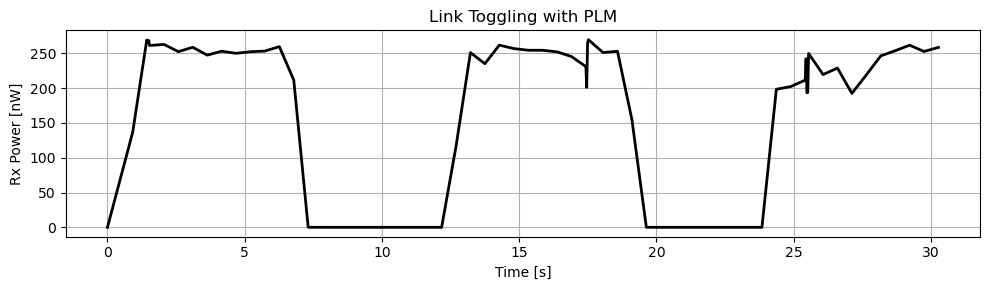

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Load CSV
# -----------------------------
filepath = Path("2026-05-19 Recording.csv")

# Find start of actual data table
with open(filepath, "r") as f:
    lines = f.readlines()

start_idx = None
for i, line in enumerate(lines):
    if line.startswith("Samples"):
        start_idx = i
        break

if start_idx is None:
    raise ValueError("Could not find data table in file.")

# Read table
df = pd.read_csv(
    filepath,
    skiprows=start_idx,
)

# Clean columns
df.columns = [c.strip() for c in df.columns]

# Remove empty columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# -----------------------------
# Create timestamps
# -----------------------------
df["Timestamp"] = pd.to_datetime(
    df["Date (MM/dd/yyyy)"].astype(str) + " " +
    df["Time of day (hh:mm:ss)"].astype(str)
)

# -----------------------------
# Relative time axis in seconds
# -----------------------------
t0 = df["Timestamp"].iloc[0]

df["Time (s)"] = (
    df["Timestamp"] - t0
).dt.total_seconds()

# -----------------------------
# Convert power to nanowatts
# -----------------------------
df["Power (nW)"] = (
    pd.to_numeric(df["Power (W)"], errors="coerce")
    * 1e9
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 3))

plt.plot(
    df["Time (s)"],
    df["Power (nW)"],
    linewidth=2,
    c = 'k'
)

# plt.xlabel("Time [s]", fontsize = 15)
# plt.ylabel("Rx Power [nW]", fontsize = 15)
# plt.title("Link Toggling with PLM", fontsize = 20)

plt.xlabel("Time [s]")
plt.ylabel("Rx Power [nW]")
plt.title("Link Toggling with PLM")

plt.grid(True)

plt.tight_layout()

plt.savefig("my_plot.pdf")